# Object Localization with TensorFlow

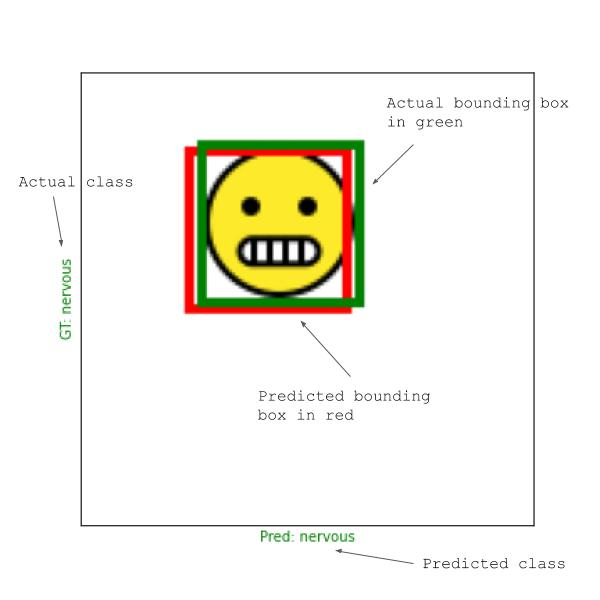

All emojis designed by [OpenMoji](https://openmoji.org/) – the open-source emoji and icon project.

##Download and Visualize Data

In [24]:
!wget https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
!mkdir emojis
!unzip -q openmoji-72x72-color.zip -d ./emojis
!pip install tensorflow

--2026-04-03 22:12:38--  https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip [following]
--2026-04-03 22:12:38--  https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/114106318/9532d5d3-3294-49ab-b7f9-5da918081758?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-03T23%3A05%3A35Z&rscd=attachment%3B+filename%3Dopenmoji-72x72-color.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-03T22%3A05%3A

In [25]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image, ImageDraw
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D, BatchNormalization, Dropout

print('Using TensorFlow version', tf.__version__)

Using TensorFlow version 2.19.0


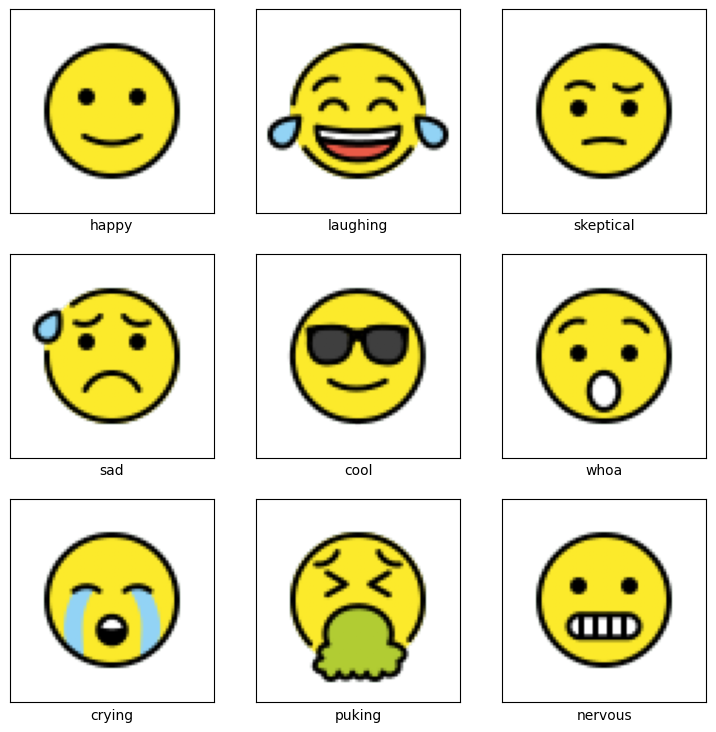

In [26]:
emojis = {
    0: {'name': 'happy', 'file': '1F642.png'},
    1: {'name': 'laughing', 'file': '1F602.png'},
    2: {'name': 'skeptical', 'file': '1F928.png'},
    3: {'name': 'sad', 'file': '1F630.png'},
    4: {'name': 'cool', 'file': '1F60E.png'},
    5: {'name': 'whoa', 'file': '1F62F.png'},
    6: {'name': 'crying', 'file': '1F62D.png'},
    7: {'name': 'puking', 'file': '1F92E.png'},
    8: {'name': 'nervous', 'file': '1F62C.png'}
}

plt.figure(figsize=(9, 9))

for i, (j, e) in enumerate(emojis.items()):
    plt.subplot(3, 3, i + 1)
    plt.imshow(plt.imread(os.path.join('emojis', e['file'])))
    plt.xlabel(e['name'])
    plt.xticks([])
    plt.yticks([])
plt.show()

## Create Examples

In [27]:
for class_id, values in emojis.items():
    png_file = Image.open(os.path.join('emojis', values['file'])).convert('RGBA')
    png_file.load()
    new_file = Image.new("RGB", png_file.size, (255, 255, 255))
    new_file.paste(png_file, mask=png_file.split()[3])
    emojis[class_id]['image'] = new_file

In [28]:
def create_example():
  class_id = np.random.randint(0, 9)
  img = np.ones((144, 144, 3)) * 255
  row = np.random.randint(0, 72)
  col = np.random.randint(0, 72)
  img[row:row + 72, col:col + 72, :] = np.array(emojis[class_id]['image'])
  return img.astype('uint8'), class_id, (row+10)/144, (col+10)/144

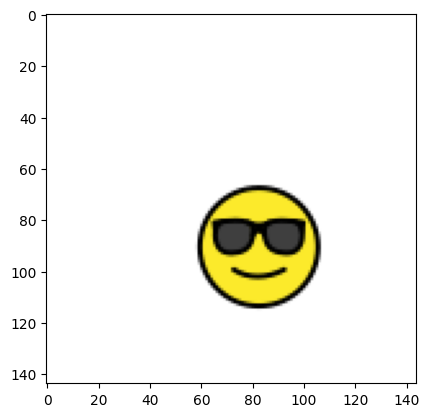

In [29]:
image, class_id, row, col = create_example()
plt.imshow(image)
plt.show()

## Plot Bounding Boxes

In [30]:
def plot_bounding_box(image, actual_coords, pred_coords = [], norm=False):
  if norm:
    image *= 255.
    image = image.astype('uint8')
  image = Image.fromarray(image)
  draw = ImageDraw.Draw(image)

  row, col = actual_coords
  row *= 144
  col *= 144
  draw.rectangle((col, row, col+52, row+52), outline = "green", width = 3)

  if len(pred_coords) == 2:
    row, col = pred_coords
    row *= 144
    col *= 144
    draw.rectangle((col, row, col+52, row+52), outline = "red", width = 3)

  return image

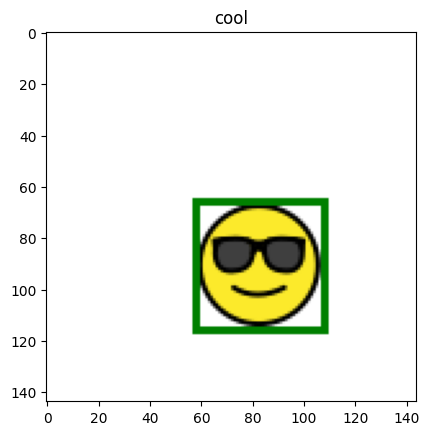

In [31]:
image = plot_bounding_box(image, [row, col])
plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()

## Data Generator

In [32]:
def data_generator(batch_size=16):
    while True:
        x_batch = np.zeros((batch_size, 144, 144, 3), dtype=np.float32)
        y_batch = np.zeros((batch_size, 9), dtype=np.float32)
        bbox_batch = np.zeros((batch_size, 2), dtype=np.float32)

        for i in range(0, batch_size):
            image, class_id, row, col = create_example()
            x_batch[i] = image / 255.
            y_batch[i, class_id] = 1.0
            bbox_batch[i] = np.array([row, col], dtype=np.float32)
        yield {'image': x_batch}, {'class_out': y_batch, 'box_out': bbox_batch}

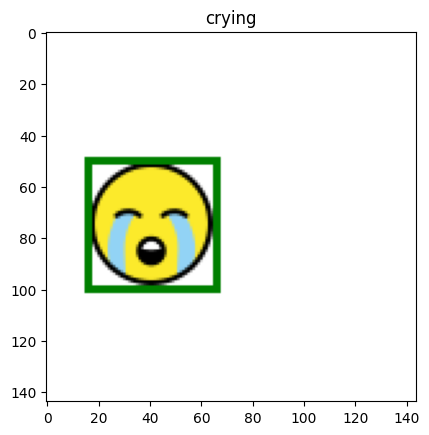

In [33]:
example, label = next(data_generator(1))
image = example['image'][0]
class_id = np.argmax(label['class_out'][0])
coords = label['box_out'][0]

image = plot_bounding_box(image, coords, norm=True)
plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()

## Model

In [34]:
input_layer = Input(shape = (144, 144, 3), name = "image")

x = input_layer

for i in range(0, 5):
  n_filters = 2 ** (4+i)
  x = Conv2D(n_filters, 3, activation = "relu")(x)
  x = BatchNormalization()(x)
  x = MaxPool2D(2)(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)

class_out = Dense(9, activation='softmax', name='class_out')(x)
box_out = Dense(2, name='box_out')(x)

model = tf.keras.models.Model(input_layer, [class_out, box_out])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 144, 144,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 142, 142,  │        448 │ image[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 142, 142,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 71, 71,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 69, 69,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 69,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 34, 34,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 5, 5, 256) │    295,168 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 5, 256) │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 2, 2, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1024)      │          0 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 659,819 (2.52 MB)

 Trainable params: 658,827 (2.51 MB)

 Non-trainable params: 992 (3.88 KB)

## Custom Metric: IoU

In [35]:
class IoU(tf.keras.metrics.Metric):
    def __init__(self, **kwargs):
        super(IoU, self).__init__(**kwargs)
        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.num_ex = self.add_weight(name='num_ex', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        def get_box(y):
            rows, cols = y[:, 0], y[:, 1]
            rows, cols = rows * 144, cols * 144
            y1, y2 = rows, rows + 52
            x1, x2 = cols, cols + 52
            return x1, y1, x2, y2

        def get_area(x1, y1, x2, y2):
            # Ensure positive dimensions for area calculation
            width = tf.maximum(0., x2 - x1)
            height = tf.maximum(0., y2 - y1)
            return width * height

        gt_x1, gt_y1, gt_x2, gt_y2 = get_box(y_true)
        p_x1, p_y1, p_x2, p_y2 = get_box(y_pred)

        i_x1 = tf.maximum(gt_x1, p_x1)
        i_y1 = tf.maximum(gt_y1, p_y1)
        i_x2 = tf.minimum(gt_x2, p_x2)
        i_y2 = tf.minimum(gt_y2, p_y2)

        i_area = get_area(i_x1, i_y1, i_x2, i_y2)
        gt_area = get_area(gt_x1, gt_y1, gt_x2, gt_y2)
        p_area = get_area(p_x1, p_y1, p_x2, p_y2)

        u_area = gt_area + p_area - i_area

        # Handle cases where union area is zero to avoid division by zero
        iou = tf.math.divide_no_nan(i_area, u_area)

        self.num_ex.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32)) # Increment by batch size
        self.total_iou.assign_add(tf.reduce_sum(iou))

    def result(self):
        return tf.math.divide_no_nan(self.total_iou, self.num_ex)

    def reset_state(self):
        self.total_iou.assign(0.0)
        self.num_ex.assign(0.0)

## Compile the Model

In [36]:
model.compile(
    loss={
        'class_out': 'categorical_crossentropy',
        'box_out': 'mse'
    },
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics={
        'class_out': 'accuracy',
        'box_out': IoU(name='iou')
    }
)

## Custom Callback: Model Testing

In [37]:
def test_model(model, test_datagen):
    example, label = next(test_datagen)
    x = example['image']
    y = label['class_out']
    box = label['box_out']

    pred_y, pred_box = model.predict(x)

    pred_coords = pred_box[0]
    gt_coords = box[0]
    pred_class = np.argmax(pred_y[0])
    image = x[0]

    gt = emojis[np.argmax(y[0])]['name']
    pred_class_name = emojis[pred_class]['name']

    image = plot_bounding_box(image, gt_coords, pred_coords, norm=True)
    color = 'green' if gt == pred_class_name else 'red'

    plt.imshow(image)
    plt.xlabel(f'Pred: {pred_class_name}', color=color)
    plt.ylabel(f'GT: {gt}', color=color)
    plt.xticks([])
    plt.yticks([])

In [38]:
def test(model):
    test_datagen = data_generator(1)
    plt.figure(figsize=(16, 4))

    for i in range(0, 6):
        plt.subplot(1, 6, i + 1)
        test_model(model, test_datagen)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 861ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


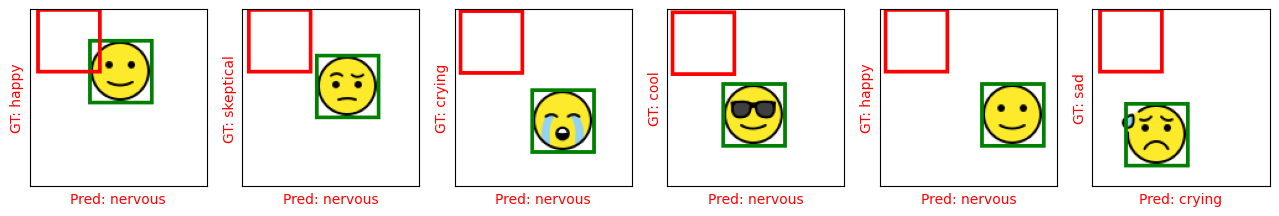

In [39]:
test(model)

In [40]:
class ShowTestImages(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        test(self.model)

## Model Training

In [41]:
tf.keras.backend.clear_session()

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


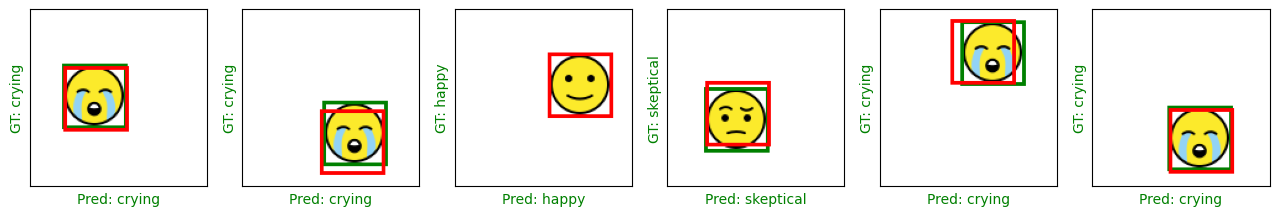

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7787 - box_out_loss: 9.5430e-04 - class_out_accuracy: 1.0000 - class_out_loss: 2.0438e-04 - loss: 0.0012 - learning_rate: 8.0000e-06
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


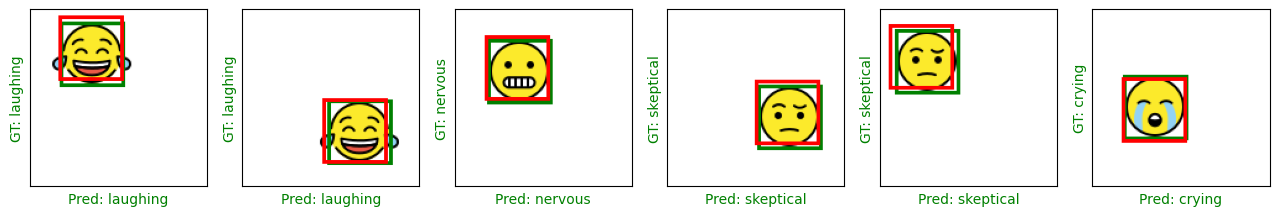

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7812 - box_out_loss: 9.3120e-04 - class_out_accuracy: 1.0000 - class_out_loss: 2.5300e-04 - loss: 0.0012 - learning_rate: 8.0000e-06
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


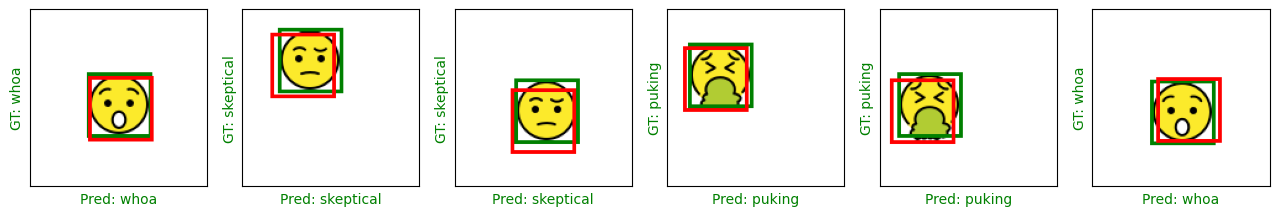

500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - box_out_iou: 0.7858 - box_out_loss: 8.8033e-04 - class_out_accuracy: 1.0000 - class_out_loss: 2.2089e-04 - loss: 0.0011 - learning_rate: 8.0000e-06
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


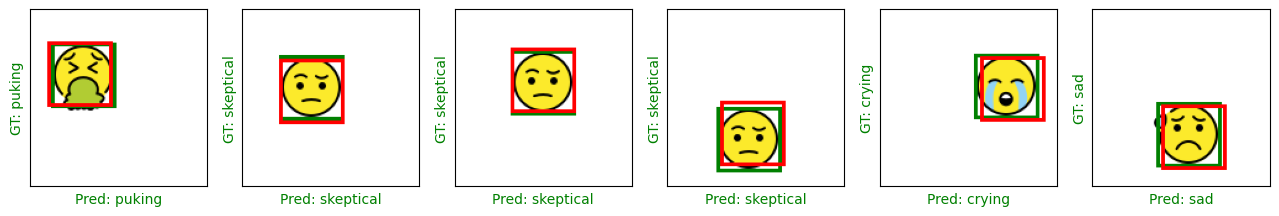

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7861 - box_out_loss: 8.9160e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.7431e-04 - loss: 0.0011 - learning_rate: 8.0000e-06
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


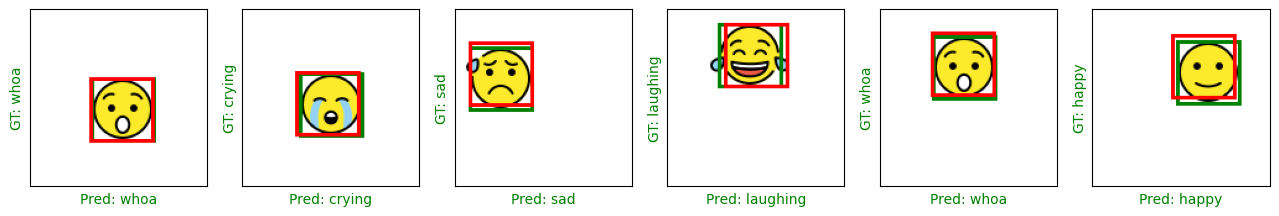

500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - box_out_iou: 0.7924 - box_out_loss: 8.1591e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.4058e-04 - loss: 9.5649e-04 - learning_rate: 1.6000e-06
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


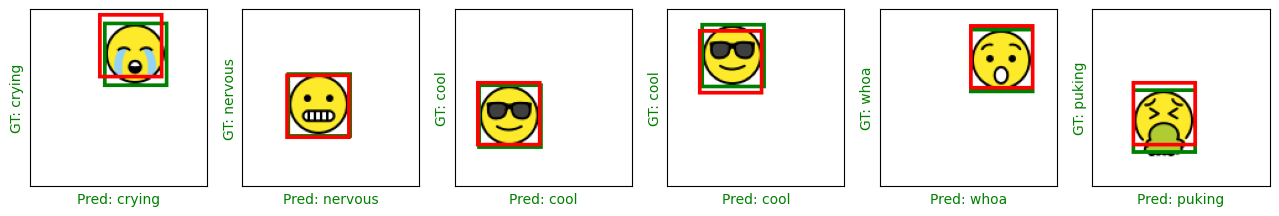

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7958 - box_out_loss: 7.9227e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.6299e-04 - loss: 9.5526e-04 - learning_rate: 1.6000e-06
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


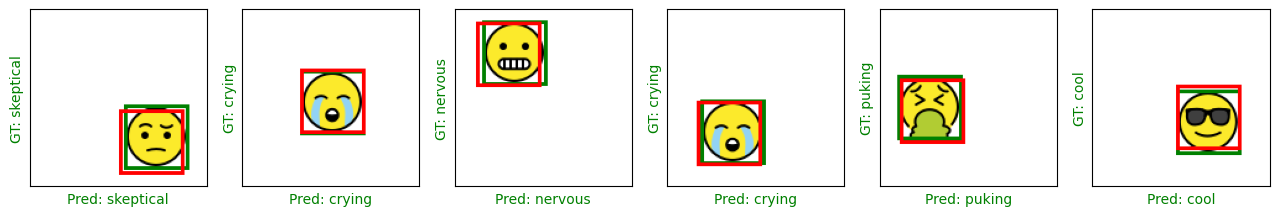

500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - box_out_iou: 0.7952 - box_out_loss: 7.9144e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.7428e-04 - loss: 9.6571e-04 - learning_rate: 1.6000e-06
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


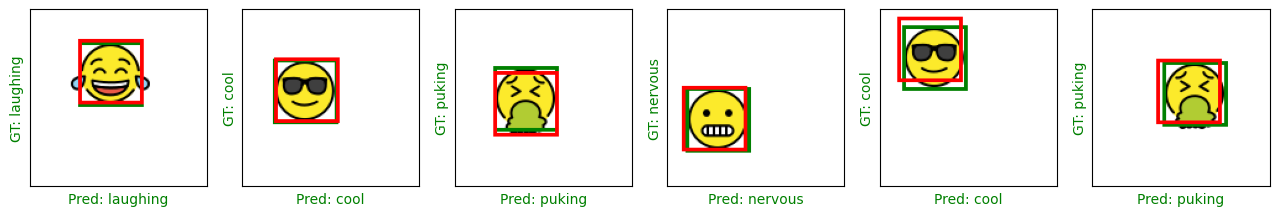

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - box_out_iou: 0.7957 - box_out_loss: 7.8340e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.4106e-04 - loss: 9.2446e-04 - learning_rate: 1.6000e-06
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


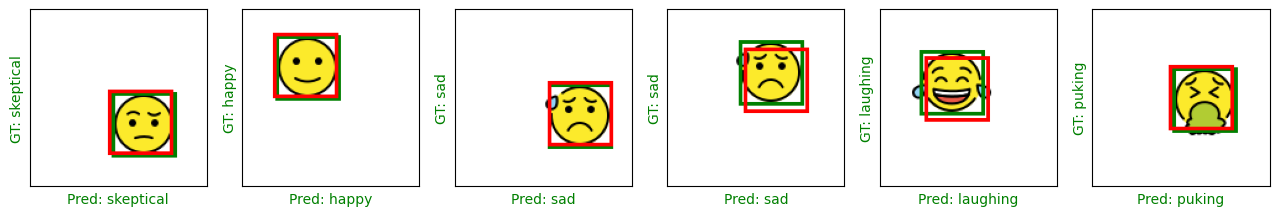

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - box_out_iou: 0.7962 - box_out_loss: 7.9299e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.3568e-04 - loss: 9.2867e-04 - learning_rate: 1.6000e-06
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


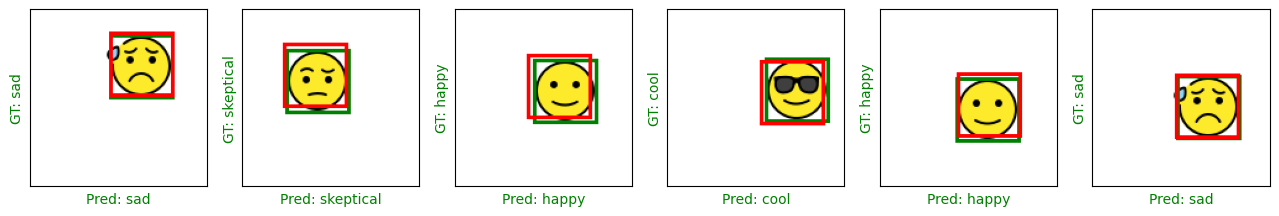

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7980 - box_out_loss: 7.6916e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.5314e-04 - loss: 9.2230e-04 - learning_rate: 3.2000e-07
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


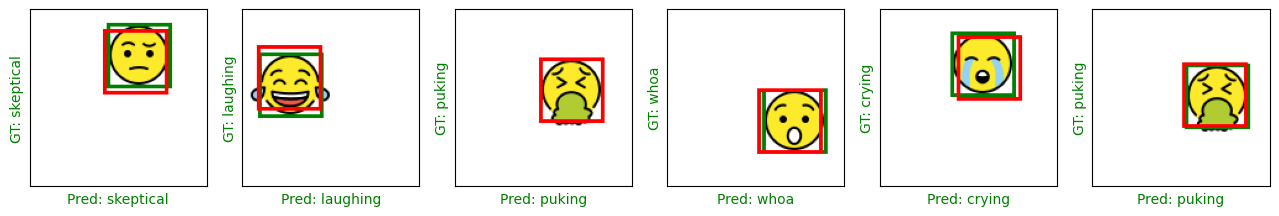

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7978 - box_out_loss: 7.7355e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.4004e-04 - loss: 9.1359e-04 - learning_rate: 3.2000e-07
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


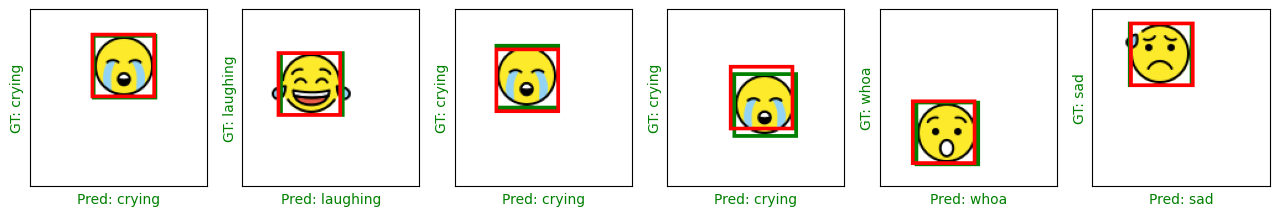

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7951 - box_out_loss: 7.8738e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.6266e-04 - loss: 9.5004e-04 - learning_rate: 3.2000e-07
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


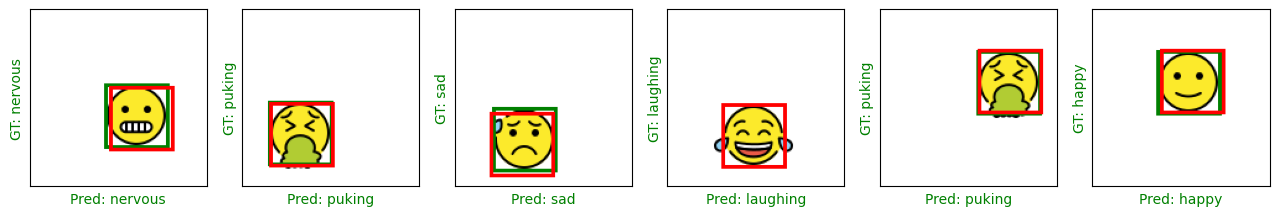

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - box_out_iou: 0.7985 - box_out_loss: 7.6591e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.4301e-04 - loss: 9.0892e-04 - learning_rate: 3.2000e-07
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


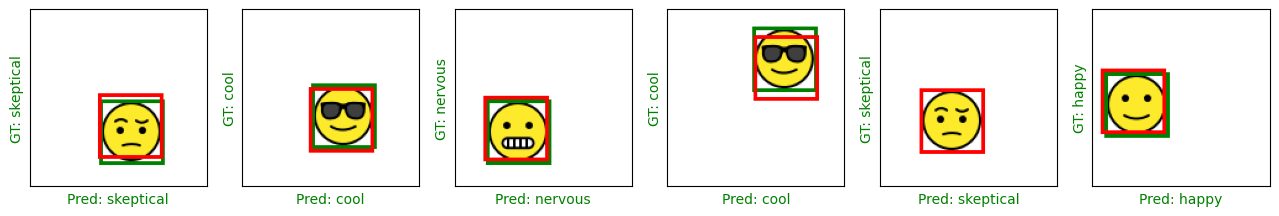

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - box_out_iou: 0.7987 - box_out_loss: 7.6052e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.4789e-04 - loss: 9.0841e-04 - learning_rate: 3.2000e-07
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


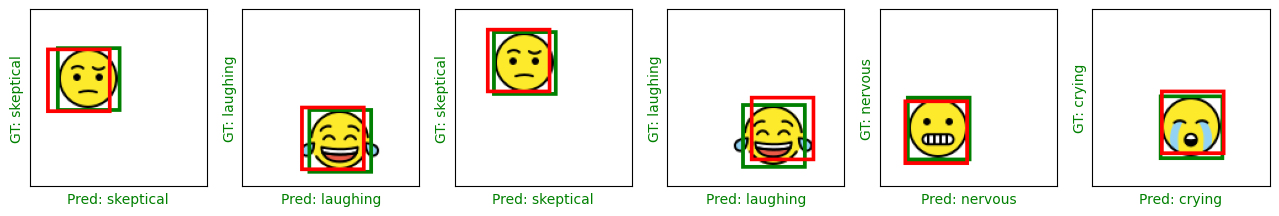

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - box_out_iou: 0.7975 - box_out_loss: 7.8417e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.4140e-04 - loss: 9.2557e-04 - learning_rate: 3.0000e-07
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


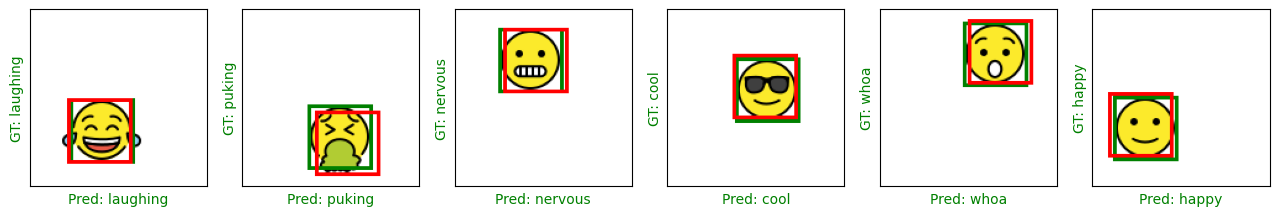

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.8001 - box_out_loss: 7.5069e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.3489e-04 - loss: 8.8558e-04 - learning_rate: 3.0000e-07
Epoch 17/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


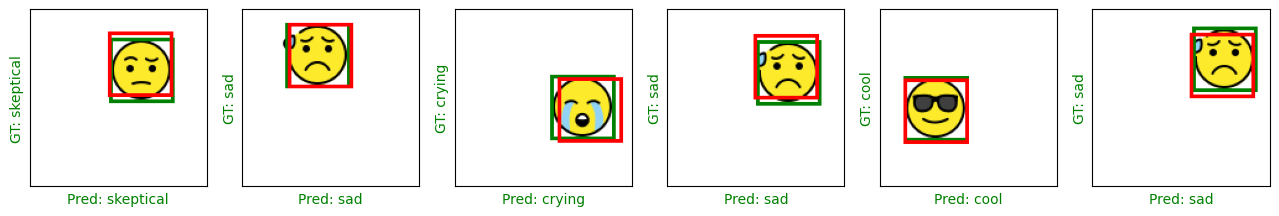

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - box_out_iou: 0.7974 - box_out_loss: 7.6885e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.4821e-04 - loss: 9.1706e-04 - learning_rate: 3.0000e-07
Epoch 18/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


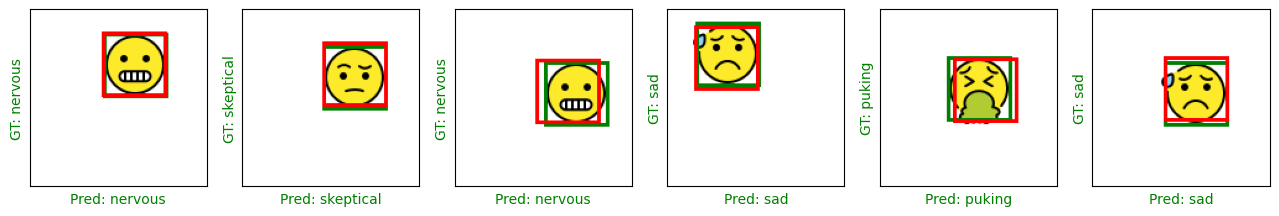

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7994 - box_out_loss: 7.5534e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.8004e-04 - loss: 9.3537e-04 - learning_rate: 3.0000e-07
Epoch 19/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


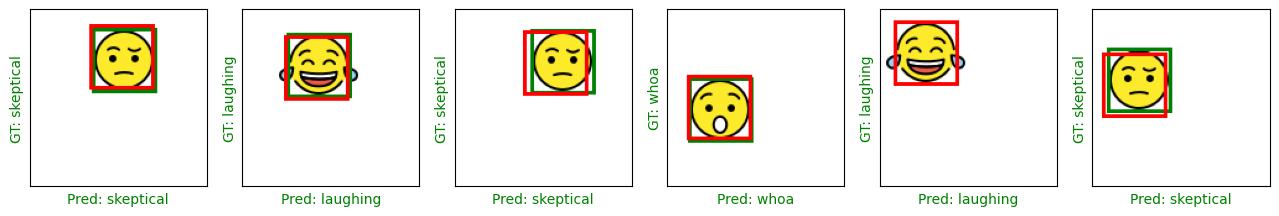

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - box_out_iou: 0.7987 - box_out_loss: 7.5966e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.5469e-04 - loss: 9.1435e-04 - learning_rate: 3.0000e-07


In [44]:
def lr_schedule(epoch, lr):
    if (epoch + 1) % 5 == 0:
        lr *= 0.2
    return max(lr, 3e-7)

_ = model.fit(
    data_generator(),
    epochs=50,
    steps_per_epoch=500,
    callbacks=[
        ShowTestImages(),
        tf.keras.callbacks.EarlyStopping(monitor='box_out_iou', patience=3, mode='max'),
        tf.keras.callbacks.LearningRateScheduler(lr_schedule)
    ]
)